### **4.3 ARMA and ARIMA Process**

**Overview**

In this activity, you will explore **ARMA** and **ARIMA** models for time series forecasting using a fictional industrial dataset. You will be asked to complete key parts of the code, with a particular focus on:

- Model selection and evaluation

- Interpretation of time series patterns

- Communicating results effectively through visualisations

Analysts should view these skills as a competitive advantage, especially in situations where machine learning alone cannot explain why a pattern is important or what action should follow from a forecast.

**ARMA process**

The ARMA (AutoRegressive Moving Average) model is a time series model frequently used when data are **stationary** - meaning the statistical properties of the series do not change over time.

In this section, you will explore how to:

- Identify whether an ARMA model is appropriate for the data

- Interpret autocorrelation and partial autocorrelation plots (ACF & PACF)

- Fit and evaluate an ARMA model using the `statsmodels` library

---

**Dataset: `ElectricalSignaldata.csv`**

This dataset simulates data from an industrial system monitoring electrical signals emitted per minute.

- Variable: `ElectricalSignals` - *float*, representing the number of electrical signals sent each minute.
- Number of records: 1,000
- Use Case: Think of a predictive maintenance scenario where signal patterns may help detect anomalies or forecast potential failures in an electrical system.

**Note**: These are fictional data. Focus on technique, critical interpretation, and communication - not on real-world validity.

<img src="Id_MAq_process.png" alt="Autoregression Model Identification" width="700">

**Library Imports and Setup**

Before we begin modelling, we need to import the relevant libvraries. These cover a range of tasks including:

- **Data manipulation and plotting**: Using `pandas`, `numpy`, and `matplotlib`

- **Time series modelling**: Tools from `statsmodels` for building and diagnosing ARMA/ARIMA models

- **Model evaluation**: Metrics like MAE and RMSE from `sklearn` to assess prediction accuracy

- **Hyperparameter tuning**: Using `itertools.product` and `tqdm` for simple grid search and progress feedback

- **Plotting configuration**: `%matplotlib inline` to show plots in the notebook, and warnings are suppressed for cleaner output

In [2]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller         # for stationarity testing
from statsmodels.tsa.statespace.sarimax import SARIMAX # for advanced modelling
from statsmodels.graphics.tsaplots import plot_acf     # for autocorrelation plots
from statsmodels.graphics.tsaplots import plot_pacf    # for partial autocorrelation plots
from statsmodels.tsa.arima_process import ArmaProcess  # for simulating ARMA processes

# Data manipulation
import pandas as pd
import numpy as np

# Machine learning tools from the scikit-learn library
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Model tuning and visual feedback
from tqdm.notebook import tqdm
from itertools import product

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Read the dataset
df = pd.read_csv("./data/ElectricalSignaldata.csv")

In [5]:
df.head()

,ElectricalSignals
0,0.496714
1,0.472694
2,0.679240
3,2.330099
4,1.905506


**Plotting the Raw Time Series**

Before applying any models, it is useful to visualise the data. As before, this initial plot helps identify patterns, trends, seasonality, or potential anomalies in the signal. We will use a simple line plot to get a sense of the overall behaviour of the time series.

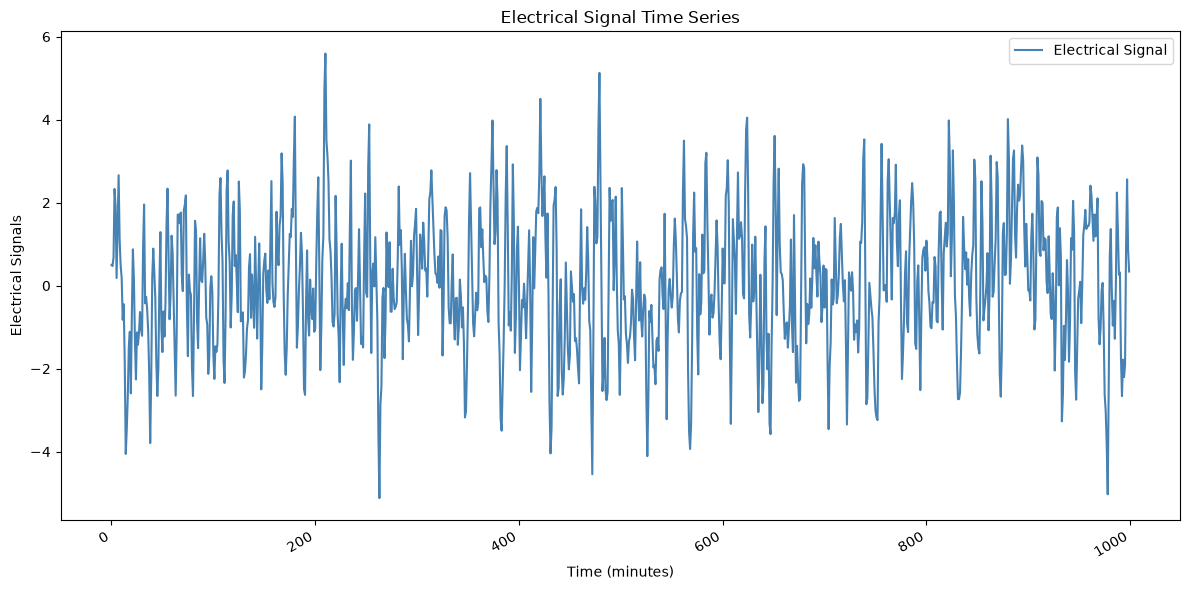

In [6]:
# Plot the electrical signal time series
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the signal
ax.plot(df["ElectricalSignals"], color='steelblue', label='Electrical Signal')
ax.set_title("Electrical Signal Time Series")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Electrical Signals")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Testing for Stationarity**

To apply an ARMA model, the time series should be stationary. We will use the Aumented Dickey-Fuller (ADF) test to check this. The test evaluates the null hypothesis that a unit root is present (i.e. the series is non-stationary). A low p-value (typically below 0.05) suggests the data is stationary.

In [7]:
# Check for stationarity using the Augmented Dickey-Fuller test
ADF_result = adfuller(df["ElectricalSignals"])

print("ADF Statistic: %f" % ADF_result[0])
print("p-value: %f" % ADF_result[1])
for key, value in ADF_result[4].items():
    print(f"Critical Value ({key}): {value:.3f}")

ADF Statistic: -6.429879
p-value: 0.000000
Critical Value (1%): -3.437
Critical Value (5%): -2.864
Critical Value (10%): -2.568


The ADF test statistic is **-6.43** which is significantly lower (more negative) than all the critical values at the 1%, 5%, and 10% significance levels. Additionally, the **p-value** is extremely small (**1.71e-08**), well below the standard 0.05 threshold.

We can conclude that the time series is **stationary**, and we can proceed with ARMA modelling without applying differencing.

<div style="border:2px solid #00ffff; padding: 10px; border-radius: 5px; width: 1200px;">

**Note**:

The critical values in the ADF test represent thresholds for rejecting the null hypothesis at different confidence levels (1%, 5%, and 10%).

If the **ADF Statistic** is more negative than the critical value (e.g. -6.430 < -3.437 at 1%), we reject the null hypothesis and conclude that the series is likely stationary.

While the **p-value** is a quick indicator, comparing the test statistic to critical values gives a more transparent understanding of the result - and is often preferred in formal setting.
</div>

**Autocorrelation Function (ACF) Plot**

The ACF plot shows how correlated the time series is with its own past values. This helps in identifying the **MA (Moving Average)** component of an ARMA model.

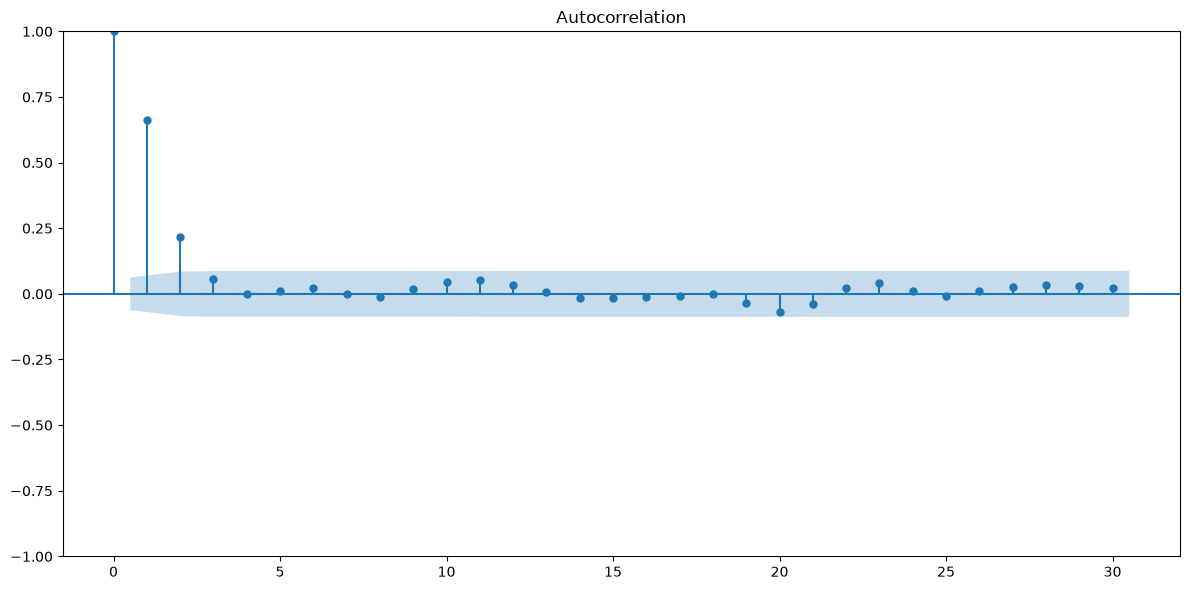

In [8]:
# Plot the Autocorrelation Function (ACF)
fig = plot_acf(df["ElectricalSignals"])

# Adjust plot size
fig.set_size_inches(12, 6)

# Improve layout
plt.tight_layout()

plt.show()

**Interpreting the ACF Plot**

The autocorrelation plot shows: